In [1]:
# SVR

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')

dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [4]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [5]:
# Splitting the dataset into the Training set and Test set
"""from sklearn.cross_validation import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)"""

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(X)

In [6]:
X

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [7]:
sc_y = StandardScaler()
y = np.squeeze(sc_y.fit_transform(y.reshape(-1, 1)))

In [8]:
y

array([-0.72004253, -0.70243757, -0.66722767, -0.59680786, -0.49117815,
       -0.35033854, -0.17428902,  0.17781001,  0.88200808,  2.64250325])

In [46]:
# Fitting SVR to the dataset
from sklearn.svm import SVR
regressor = SVR(epsilon=0.07)
regressor.fit(X, y)

SVR(epsilon=0.07)

In [47]:
# Predicting a new result
y_pred = regressor.predict([[6.5]])
y_pred = sc_y.inverse_transform(y_pred.reshape(-1, 1))

In [48]:
y_pred


array([[251028.48915049]])

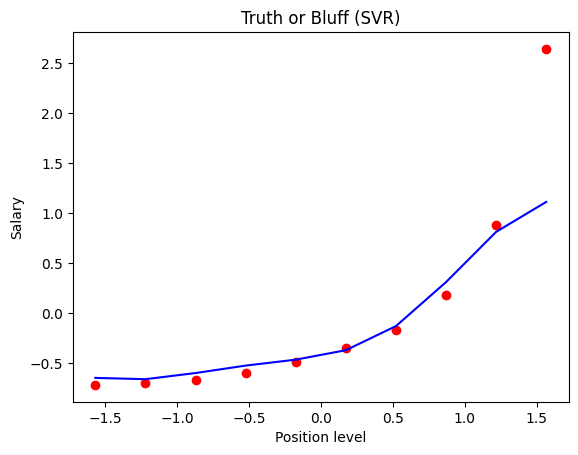

In [49]:
# Visualising the SVR results
plt.scatter(X, y, color = 'red')
plt.plot(X, regressor.predict(X), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [50]:
regressor.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.07,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [51]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predict on the training set
y_train_pred = regressor.predict(X)

# Calculate R^2
r2 = r2_score(y, y_train_pred)

# Calculate MSE (remember to inverse transform y_train_pred if needed for meaningful error in original scale)
# Since y is scaled, we calculate MSE on scaled data
mse = mean_squared_error(y, y_train_pred)

# Calculate MAE (remember to inverse transform y_train_pred if needed for meaningful error in original scale)
# Since y is scaled, we calculate MAE on scaled data
mae = mean_absolute_error(y, y_train_pred)

print(f'R-squared on training set: {r2:.4f}')
print(f'Mean Squared Error on training set (scaled): {mse:.4f}')
print(f'Mean Absolute Error on training set (scaled): {mae:.4f}')

# If you want to see the errors in the original scale, you would need to inverse transform both y and y_train_pred
# y_original = sc_y.inverse_transform(y.reshape(-1, 1))
# y_train_pred_original = sc_y.inverse_transform(y_train_pred.reshape(-1, 1))
# mse_original = mean_squared_error(y_original, y_train_pred_original)
# mae_original = mean_absolute_error(y_original, y_train_pred_original)
# print(f'Mean Squared Error on training set (original scale): {mse_original:.2f}')
# print(f'Mean Absolute Error on training set (original scale): {mae_original:.2f}')

R-squared on training set: 0.7615
Mean Squared Error on training set (scaled): 0.2385
Mean Absolute Error on training set (scaled): 0.2068


In [33]:
# Find the epsilon value
epsilon_value = regressor.get_params()['epsilon']
print(f'The epsilon value is: {epsilon_value}')

The epsilon value is: 0.1


# Task
Use cross-validation to find the best epsilon value for the SVR model based on the R^2 score.

## Define epsilon values

### Subtask:
Create a list or range of different epsilon values to test.


**Reasoning**:
Create a list of epsilon values to be used for cross-validation.



In [52]:
epsilon_values = [0.0, 0.1, 0.2, 0.5, 1.0]

## Set up cross-validation

### Subtask:
Use a cross-validation strategy, such as K-Fold cross-validation.


**Reasoning**:
Import the KFold class and instantiate a KFold object with 5 splits.



In [54]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

## Iterate and evaluate

### Subtask:
For each epsilon value, train an SVR model using the training data and evaluate its performance (R^2) using cross-validation.


**Reasoning**:
Iterate through epsilon values, perform cross-validation for each, calculate the mean R^2 score, and store it.



In [55]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

r2_scores = []

for epsilon in epsilon_values:
    svr_model = SVR(epsilon=epsilon)
    scores = cross_val_score(svr_model, X, y, cv=kf, scoring='r2')
    r2_scores.append(scores.mean())

print("Average R^2 scores for each epsilon value:")
for i, epsilon in enumerate(epsilon_values):
    print(f"Epsilon: {epsilon}, Average R^2: {r2_scores[i]:.4f}")

Average R^2 scores for each epsilon value:
Epsilon: 0.0, Average R^2: 0.6697
Epsilon: 0.1, Average R^2: 0.5467
Epsilon: 0.2, Average R^2: 0.1609
Epsilon: 0.5, Average R^2: -2.5743
Epsilon: 1.0, Average R^2: -11.7511


## Store results

### Subtask:
Keep track of the epsilon values and their corresponding R^2 scores.


**Reasoning**:
Create a dictionary to store epsilon values and their corresponding R^2 scores by iterating through the two lists and pairing the values.



In [57]:
epsilon_r2_scores = {}
for epsilon, r2 in zip(epsilon_values, r2_scores):
    epsilon_r2_scores[epsilon] = r2

print("\nEpsilon values and their corresponding average R^2 scores:")
for epsilon, r2 in epsilon_r2_scores.items():
    print(f"Epsilon: {epsilon}, Average R^2: {r2:.4f}")


Epsilon values and their corresponding average R^2 scores:
Epsilon: 0.0, Average R^2: 0.6697
Epsilon: 0.1, Average R^2: 0.5467
Epsilon: 0.2, Average R^2: 0.1609
Epsilon: 0.5, Average R^2: -2.5743
Epsilon: 1.0, Average R^2: -11.7511


## Find best epsilon

### Subtask:
Identify the epsilon value that resulted in the highest average R^2 score across the cross-validation folds.


**Reasoning**:
Find the epsilon value with the maximum R^2 score from the `epsilon_r2_scores` dictionary and store it in the `best_epsilon` variable, then print it.



In [59]:
best_epsilon = max(epsilon_r2_scores, key=epsilon_r2_scores.get)
print(f'The best epsilon value is: {best_epsilon}')

The best epsilon value is: 0.0


## Report results

### Subtask:
Display the R^2 scores for each epsilon value and the best epsilon found.


**Reasoning**:
Display the R^2 scores for each epsilon value and the best epsilon found as requested in the subtask.

